In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 395
Columns: 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    

In [3]:
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [4]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [6]:
df["Average_Score"] = (df["G1"] + df["G2"] + df["G3"]) / 3

df[["G1", "G2", "G3", "Average_Score"]].head()

,G1,G2,G3,Average_Score
0,5,6,6,5.666667
1,5,5,6,5.333333
2,7,8,10,8.333333
3,15,14,15,14.666667
4,6,10,10,8.666667


In [7]:
def performance_category(score):
    if score >= 15:
        return "Excellent"
    elif score >= 10:
        return "Good"
    else:
        return "Needs Improvement"

df["Performance"] = df["Average_Score"].apply(performance_category)

df[["Average_Score", "Performance"]].head()

,Average_Score,Performance
0,5.666667,Needs Improvement
1,5.333333,Needs Improvement
2,8.333333,Needs Improvement
3,14.666667,Good
4,8.666667,Needs Improvement


In [8]:
print(df[["age", "absences", "G1", "G2", "G3", "Average_Score"]].describe())

              age    absences          G1          G2          G3  \
count  395.000000  395.000000  395.000000  395.000000  395.000000   
mean    16.696203    5.708861   10.908861   10.713924   10.415190   
std      1.276043    8.003096    3.319195    3.761505    4.581443   
min     15.000000    0.000000    3.000000    0.000000    0.000000   
25%     16.000000    0.000000    8.000000    9.000000    8.000000   
50%     17.000000    4.000000   11.000000   11.000000   11.000000   
75%     18.000000    8.000000   13.000000   13.000000   14.000000   
max     22.000000   75.000000   19.000000   19.000000   20.000000   

       Average_Score  
count     395.000000  
mean       10.679325  
std         3.696786  
min         1.333333  
25%         8.333333  
50%        10.666667  
75%        13.333333  
max        19.333333  


In [9]:
gender_performance = df.groupby("sex")["G3"].mean()

print(gender_performance)

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


In [11]:
parent_education = df.groupby("Medu")["G3"].mean()

print(parent_education)

Medu
0    13.000000
1     8.677966
2     9.728155
3    10.303030
4    11.763359
Name: G3, dtype: float64


In [12]:
print(df[["absences", "G3"]].corr())

          absences        G3
absences  1.000000  0.034247
G3        0.034247  1.000000


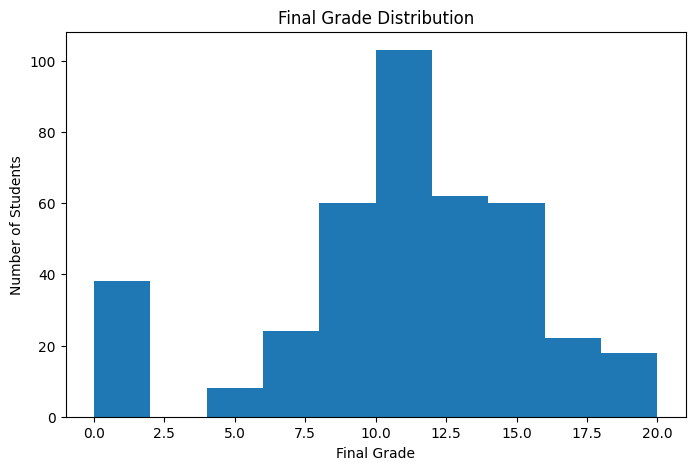

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["G3"], bins=10)

plt.title("Final Grade Distribution")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

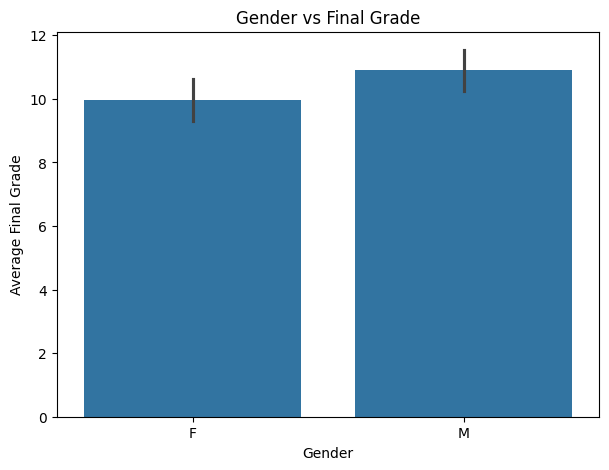

In [15]:
plt.figure(figsize=(7,5))

sns.barplot(x="sex", y="G3", data=df)

plt.title("Gender vs Final Grade")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")

plt.show()

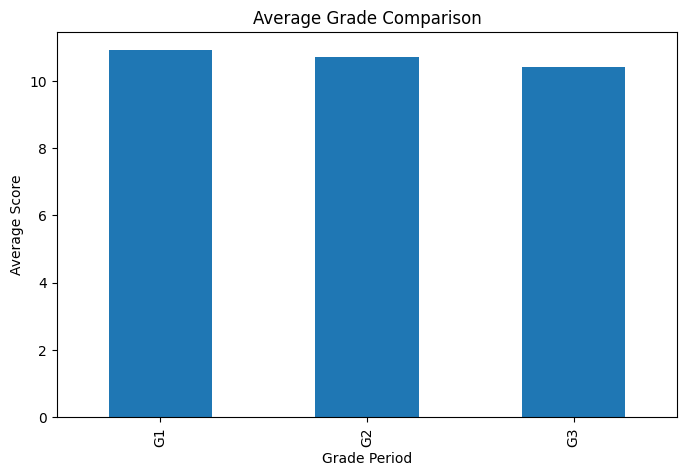

In [16]:
plt.figure(figsize=(8,5))

df[["G1", "G2", "G3"]].mean().plot(kind="bar")

plt.title("Average Grade Comparison")
plt.xlabel("Grade Period")
plt.ylabel("Average Score")

plt.show()

In [17]:
df.to_csv("student_performance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
